# Solar Yield Model Sweep

This notebook keeps the current solar feature pipeline and compares AutoGluon tabular presets on a shuffled train/test split.

In [1]:
import logging
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

# Walk upwards until we find the repo root (where "common" lives)
p = Path.cwd()
while p != p.parent and not (p / "common").exists():
    p = p.parent
sys.path.insert(0, str(p))

# Find repo root (where env.local lives)
env_root = Path.cwd()
while env_root != env_root.parent and not (env_root / "env.local").exists():
    env_root = env_root.parent

load_dotenv(env_root / "env.local")
print("Loaded env.local:", env_root / "env.local")

from common.db_repository import DbRepository
from predicthelper import PredictHelper

Loaded env.local: /home/gerbrand/PycharmProjects/EnergySchedulerNuc/env.local


In [2]:
connection_string = os.environ.get("energydb")
repo = DbRepository(connection_string=connection_string, logger=logging.getLogger(__name__))
try:
    rows = repo.get_hourly_solar_with_weather()
finally:
    repo.close()

helper = PredictHelper("Europe/Amsterdam")
df = helper.build_feature_dataframe(rows)

# Clean up any missing data
df = df.dropna().sort_values("Timestamp").reset_index(drop=True)

# Normalize timestamps to UTC and drop tz for modeling
df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True)
df["Timestamp"] = df["Timestamp"].dt.tz_convert("UTC").dt.tz_localize(None)
df.head()

,Timestamp,solar_total,pressure,temperature,cloud_are_fraction,precipitation,humidity,wind_from_direction,wind_speed,Sun_Angle,Sun_Angle_Trend,hour_sin,hour_cos,wd_sin,wd_cos
0,2025-05-11 20:00:00,0.0,1011.799988,17.5,0.0,0.0,54.000000,88.900002,3.7,0.0,-1,-0.500000,0.866025,-0.781831,0.62349
1,2025-05-11 21:00:00,0.0,1011.900024,16.9,0.0,0.0,56.299999,105.300003,3.5,0.0,-1,-0.258819,0.965926,-0.781831,0.62349
2,2025-05-11 22:00:00,0.0,1012.099976,15.9,0.0,0.0,62.799999,99.199997,3.4,0.0,-1,0.000000,1.000000,0.000000,1.00000
3,2025-05-11 23:00:00,0.0,1012.000000,15.5,0.0,0.0,65.699997,101.500000,3.6,0.0,-1,0.258819,0.965926,0.000000,1.00000
4,2025-05-12 00:00:00,0.0,1012.099976,14.7,0.0,0.0,69.000000,106.500000,3.8,0.0,-1,0.500000,0.866025,0.000000,1.00000


In [3]:
target_col = "solar_total"
feature_cols = [
    "pressure",
    "temperature",
    "cloud_are_fraction",
    "precipitation",
    "humidity",
    "wind_from_direction",
    "wind_speed",
    "Sun_Angle",
    "Sun_Angle_Trend",
    "hour_sin",
    "hour_cos",
    "wd_sin",
    "wd_cos",
]

model_df = df[["Timestamp", target_col, *feature_cols]].copy()
model_df.head()

,Timestamp,solar_total,pressure,temperature,cloud_are_fraction,precipitation,humidity,wind_from_direction,wind_speed,Sun_Angle,Sun_Angle_Trend,hour_sin,hour_cos,wd_sin,wd_cos
0,2025-05-11 20:00:00,0.0,1011.799988,17.5,0.0,0.0,54.000000,88.900002,3.7,0.0,-1,-0.500000,0.866025,-0.781831,0.62349
1,2025-05-11 21:00:00,0.0,1011.900024,16.9,0.0,0.0,56.299999,105.300003,3.5,0.0,-1,-0.258819,0.965926,-0.781831,0.62349
2,2025-05-11 22:00:00,0.0,1012.099976,15.9,0.0,0.0,62.799999,99.199997,3.4,0.0,-1,0.000000,1.000000,0.000000,1.00000
3,2025-05-11 23:00:00,0.0,1012.000000,15.5,0.0,0.0,65.699997,101.500000,3.6,0.0,-1,0.258819,0.965926,0.000000,1.00000
4,2025-05-12 00:00:00,0.0,1012.099976,14.7,0.0,0.0,69.000000,106.500000,3.8,0.0,-1,0.500000,0.866025,0.000000,1.00000


## Shuffled Split

Because we are explicitly avoiding historical lags, each row is treated as an independent supervised sample. That makes a shuffled holdout valid for this experiment.

In [4]:
from sklearn.model_selection import train_test_split

SEED = 42
TEST_SIZE = 0.2

train_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True,
)

# Keep each split ordered by time for inspection and plotting.
train_df = train_df.sort_values("Timestamp").reset_index(drop=True)
test_df = test_df.sort_values("Timestamp").reset_index(drop=True)

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train rows: 3473
Test rows: 869


In [8]:
from autogluon.tabular import TabularPredictor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_data = train_df[[target_col, *feature_cols]].copy()
test_features = test_df[feature_cols].copy()
y_test = test_df[target_col].to_numpy()

MODEL_PRESETS = {
    "medium": "medium_quality",
    "good": "good_quality",
    "best": "best_quality",
}

results = []
predictions = {}
predictors = {}

for preset_name, preset_value in MODEL_PRESETS.items():
    predictor_path = Path("AutogluonModels") / f"solar_yield_{preset_name}"
    predictor = TabularPredictor(
        label=target_col,
        problem_type="regression",
        path=str(predictor_path),
        eval_metric="mean_absolute_error",
    )
    predictor.fit(
        train_data=train_data,
        presets=preset_value,
        verbosity=2,
    )
    y_pred = predictor.predict(test_features)
    y_pred = pd.Series(y_pred).clip(lower=0).to_numpy()

    predictors[preset_name] = predictor
    predictions[preset_name] = y_pred
    results.append(
        {
            "model": preset_name,
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": mean_squared_error(y_test, y_pred) ** 0.5,
            "r2": r2_score(y_test, y_pred),
            "leader": predictor.leaderboard(test_df[[target_col, *feature_cols]], silent=True).iloc[0]["model"],
        }
    )

results_df = pd.DataFrame(results).sort_values(["mae", "rmse"]).reset_index(drop=True)
results_df


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Feb 19 19:54:01 UTC 2026
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       4.90 GB / 15.32 GB (32.0%)
Disk Space Avail:   195.88 GB / 411.34 GB (47.6%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ...
AutoGluon will save models to "/home/gerbrand/PycharmProjects/EnergySchedulerNuc/SolarYieldPrediction/AutogluonModels/solar_yield_medium"
Train Data Rows:    3473
Train Data Columns: 13
Label Column:       solar_total
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    4941.54 MB
	Tra

(_ray_fit pid=131040) [1000]	valid_set's l1: 0.0157403


(_dystack pid=130592) 	-0.0175	 = Validation score   (-mean_absolute_error)
(_dystack pid=130592) 	1.47s	 = Training   runtime
(_dystack pid=130592) 	0.1s	 = Validation runtime
(_dystack pid=130592) Fitting model: LightGBM_BAG_L1 ... Training model for up to 592.04s of the 890.86s of remaining time.
(_dystack pid=130592) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.63%)
(_dystack pid=130592) 	-0.0162	 = Validation score   (-mean_absolute_error)
(_dystack pid=130592) 	3.37s	 = Training   runtime
(_dystack pid=130592) 	0.06s	 = Validation runtime
(_dystack pid=130592) Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 583.78s of the 882.60s of remaining time.
(_dystack pid=130592) 	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=8, gpus=0, mem=0.0/2.7 GB
(_dystack pid=130592) 	-0.0161	 = Validation score   (-mean_absolute_error)
(_dystack pid=130592) 	2.68s	 = Training 

,model,mae,rmse,r2,leader
0,good,0.011339,0.026236,0.843567,NeuralNetTorch_BAG_L2_FULL
1,best,0.011387,0.026083,0.845390,NeuralNetTorch_BAG_L1
2,medium,0.012391,0.027739,0.825129,WeightedEnsemble_L2


Best AutoGluon preset: best


,Timestamp,solar_total,prediction
0,2025-05-12 04:00:00,0.00,0.000085
1,2025-05-12 08:00:00,0.02,0.027359
2,2025-05-12 10:00:00,0.07,0.070055
3,2025-05-12 13:00:00,0.33,0.313657
4,2025-05-12 19:00:00,0.00,0.000999
5,2025-05-12 22:00:00,0.00,0.000000
6,2025-05-13 01:00:00,0.00,0.000000
7,2025-05-13 02:00:00,0.00,0.000000
8,2025-05-13 04:00:00,0.00,0.000096
9,2025-05-13 05:00:00,0.00,0.002717


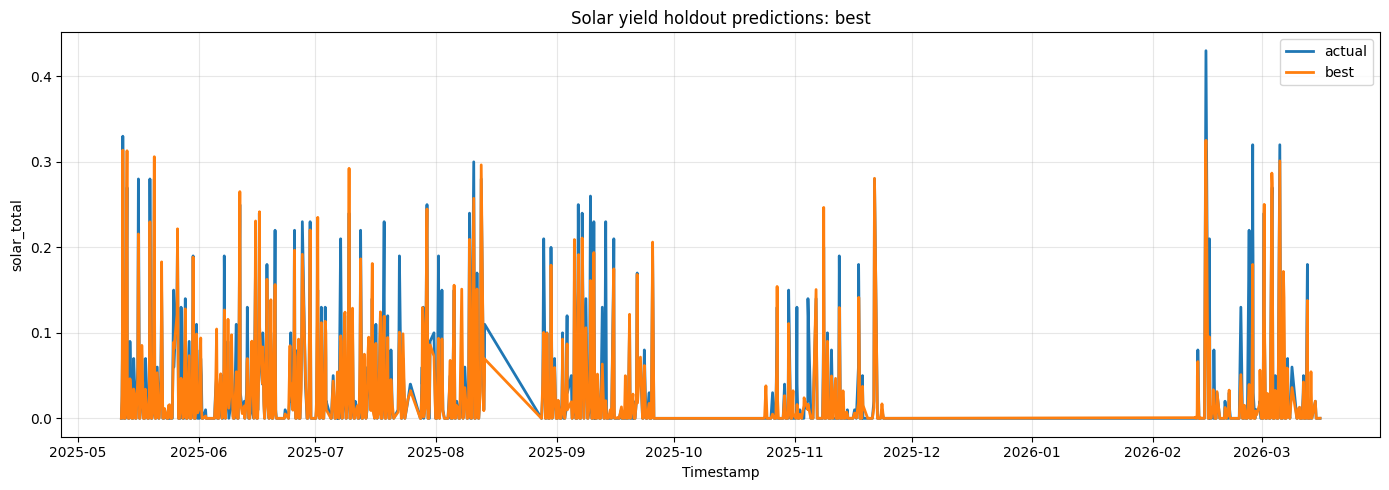

In [20]:
best_model_name = results_df.iloc[1]["model"]
plot_df = test_df[["Timestamp", target_col]].copy()
plot_df["prediction"] = predictions[best_model_name]
plot_df = plot_df.sort_values("Timestamp").reset_index(drop=True)

print("Best AutoGluon preset:", best_model_name)
display(plot_df.head(20))

plt.figure(figsize=(14, 5))
plt.plot(plot_df["Timestamp"], plot_df[target_col], label="actual", linewidth=2)
plt.plot(plot_df["Timestamp"], plot_df["prediction"], label=best_model_name, linewidth=2)
plt.title(f"Solar yield holdout predictions: {best_model_name}")
plt.xlabel("Timestamp")
plt.ylabel("solar_total")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
from pathlib import Path
import json
import shutil

selected_rank = 1  # results_df.iloc[1] = second-best row
selected_model_name = results_df.iloc[selected_rank]["model"]

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "common").exists():
    project_root = project_root.parent

source_dir = Path("AutogluonModels") / f"solar_yield_{selected_model_name}"
target_dir = project_root / "Models" / "solar_yield_model"

if not source_dir.exists():
    raise FileNotFoundError(f"AutoGluon model folder not found: {source_dir}")

target_dir.parent.mkdir(parents=True, exist_ok=True)

if target_dir.exists():
    shutil.rmtree(target_dir)

shutil.copytree(source_dir, target_dir)

metadata = {
    "selected_rank": selected_rank,
    "selected_model_name": selected_model_name,
    "results_row": results_df.iloc[selected_rank].to_dict(),
    "source_dir": str(source_dir.resolve()),
    "target_dir": str(target_dir.resolve()),
}

(target_dir / "selection.json").write_text(json.dumps(metadata, indent=2))

print(f"Saved model '{selected_model_name}' to: {target_dir}")
display(results_df.iloc[[selected_rank]])


Saved model 'best' to: /home/gerbrand/PycharmProjects/EnergySchedulerNuc/Models/solar_yield_model


,model,mae,rmse,r2,leader
1,best,0.011387,0.026083,0.84539,NeuralNetTorch_BAG_L1


In [25]:
from pathlib import Path

model_dir = Path(bag_model.path)
print("model_dir:", model_dir)

print("\nTop-level contents:")
for p in sorted(model_dir.iterdir()):
    print(("dir " if p.is_dir() else "file"), p.name)

print("\nAll files:")
for p in sorted(model_dir.rglob("*")):
    if p.is_file():
        print(p.relative_to(model_dir))




model_dir: /home/gerbrand/PycharmProjects/EnergySchedulerNuc/SolarYieldPrediction/AutogluonModels/solar_yield_best/models/NeuralNetTorch_BAG_L1

Top-level contents:
dir  S1F1
dir  S1F2
dir  S1F3
dir  S1F4
dir  S1F5
dir  S1F6
dir  S1F7
dir  S1F8
file model.pkl
dir  utils

All files:
S1F1/model.pkl
S1F2/model.pkl
S1F3/model.pkl
S1F4/model.pkl
S1F5/model.pkl
S1F6/model.pkl
S1F7/model.pkl
S1F8/model.pkl
model.pkl
utils/model_template.pkl
utils/oof.pkl


In [27]:
import pickle
from pathlib import Path

fold_model_path = Path(bag_model.path) / "S1F1" / "model.pkl"

with fold_model_path.open("rb") as f:
    fold_model = pickle.load(f)

print(type(fold_model))
print(fold_model)
print(fold_model.__dict__.keys())
net = getattr(fold_model, "model", None) or getattr(fold_model, "_model", None)
print(type(net))
print(net)


<class 'autogluon.tabular.models.tabular_nn.torch.tabular_nn_torch.TabularNeuralNetTorchModel'>
dict_keys(['name', 'path_root', 'path', 'num_classes', 'quantile_levels', 'model', 'problem_type', 'conformalize', 'label_cleaner', 'eval_metric', 'stopping_metric', 'normalize_pred_probas', 'features', 'feature_metadata', '_features_internal', '_features_internal_to_align', '_feature_metadata', '_is_features_in_same_as_ex', 'fit_time', 'predict_time', '_predict_n_size', 'predict_1_time', 'compile_time', 'val_score', '_memory_usage_estimate', '_user_params', '_user_params_aux', 'params', 'params_aux', 'params_trained', 'nondefault_params', '_is_initialized', '_is_fit_metadata_registered', '_fit_metadata', 'saved_learning_curves', '_compiler', 'random_seed', '_types_of_features', 'feature_arraycol_map', 'feature_type_map', 'features_to_drop', 'processor', 'num_dataloading_workers', '_architecture_desc', 'optimizer', 'device', 'max_batch_size', '_num_cpus_infer'])
<class 'autogluon.tabular.mod